# Boosting

In [1]:
import numpy as np
import pandas as pd
rng = np.random.RandomState(1)

- ****Bagging**** stands for *Bootstrap AGGregatING*. It uses bootstrap resampling (random sampling with replacement) to learn several models on random variations of the training set. At predict time, the predictions of each learner are aggregated to give the final predictions.

In [2]:

def generate_data(n_samples=30):

    x_min, x_max = -3, 3
    x = rng.uniform(x_min, x_max, size=n_samples)
    noise = 4.0 * rng.randn(n_samples)
    y = x**3 - 0.5 * (x + 1) ** 2 + noise
    y /= y.std()

    data_train = pd.DataFrame(x, columns=["Feature"])
    data_test = pd.DataFrame(
        np.linspace(x_max, x_min, num=300), columns=["Feature"]
    )
    target_train = pd.Series(y, name="Target")

    return data_train, data_test, target_train

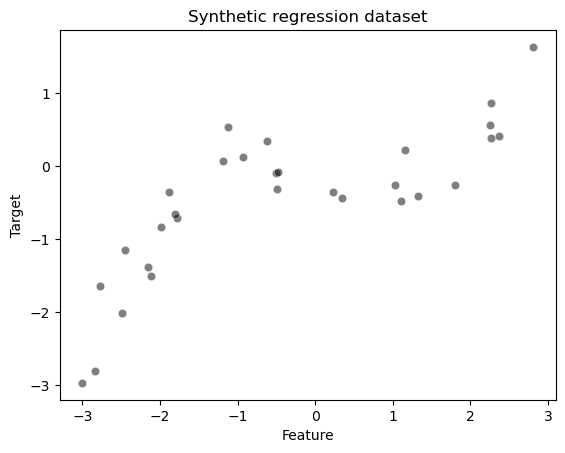

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

data_train, data_test, target_train = generate_data(n_samples=30)
sns.scatterplot(
    x=data_train["Feature"], y=target_train, color="black", alpha=0.5
)
_ = plt.title("Synthetic regression dataset")

In [4]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=3, random_state=0)
tree.fit(data_train, target_train)
y_pred = tree.predict(data_test)

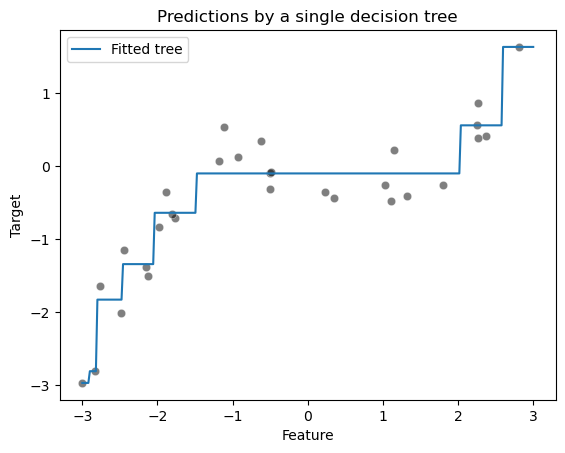

In [5]:
sns.scatterplot(
    x=data_train["Feature"], y=target_train, color="black", alpha=0.5
)
plt.plot(data_test["Feature"], y_pred, label="Fitted tree")
plt.legend()
_ = plt.title("Predictions by a single decision tree")

In [6]:
def bootstrap_sample(data, target):
    # Indices corresponding to a sampling with replacement of the same sample
    # size than the original data
    bootstrap_indices = rng.choice(
        np.arange(target.shape[0]),
        size=target.shape[0],
        replace=True,
    )
    # In pandas, we need to use `.iloc` to extract rows using an integer
    # position index:
    data_bootstrap = data.iloc[bootstrap_indices]
    target_bootstrap = target.iloc[bootstrap_indices]
    return data_bootstrap, target_bootstrap

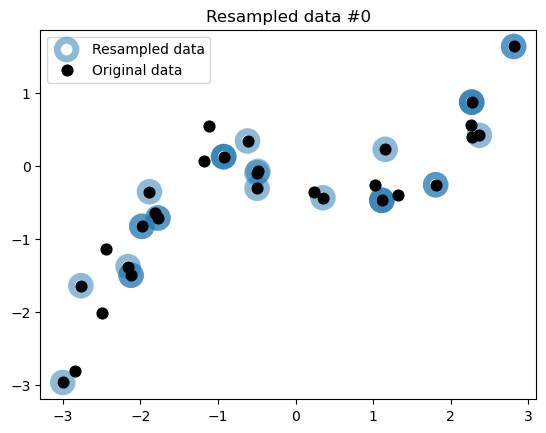

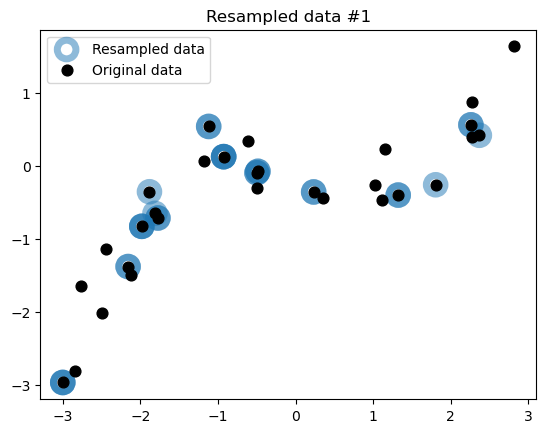

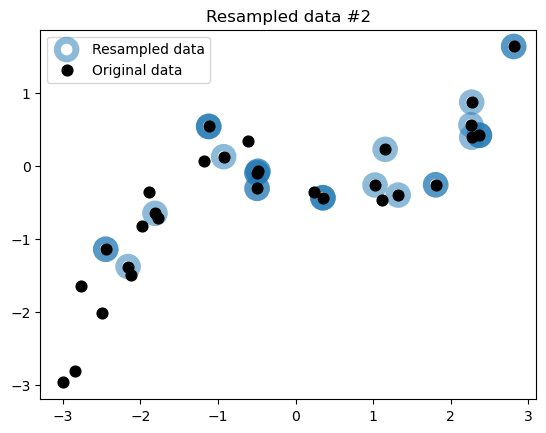

In [7]:
n_bootstraps = 3
for bootstrap_idx in range(n_bootstraps):
    # draw a bootstrap from the original data
    data_bootstrap, target_bootstrap = bootstrap_sample(
        data_train,
        target_train,
    )
    plt.figure()
    plt.scatter(
        data_bootstrap["Feature"],
        target_bootstrap,
        color="tab:blue",
        facecolors="none",
        alpha=0.5,
        label="Resampled data",
        s=180,
        linewidth=5,
    )
    plt.scatter(
        data_train["Feature"],
        target_train,
        color="black",
        s=60,
        alpha=1,
        label="Original data",
    )
    plt.title(f"Resampled data #{bootstrap_idx}")
    plt.legend()

In [8]:
data_train_huge, data_test_huge, target_train_huge = generate_data(
    n_samples=100_000
)
data_bootstrap_sample, target_bootstrap_sample = bootstrap_sample(
    data_train_huge, target_train_huge
)

ratio_unique_sample = (
    np.unique(data_bootstrap_sample).size / data_bootstrap_sample.size
)
print(
    "Percentage of samples present in the original dataset: "
    f"{ratio_unique_sample * 100:.1f}%"
)

Percentage of samples present in the original dataset: 63.2%


- The 3 generated bootstrap samples are all different from the original dataset and from each other.

## Bootstrap resampling
- Given a dataset with n data points, bootstrapping corresponds to resampling with replacement n out of such n data points uniformly at random.

- As a result, the output of the bootstrap sampling procedure is another dataset with also n data points, but likely with duplicates. As a consequence, there are also data points from the original dataset that are never selected to appear in a bootstrap sample (by chance). Those data points that are left away are often referred to as the out-of-bag sample.

In [10]:
bag_of_trees = []
for bootstrap_idx in range(n_bootstraps):
    tree = DecisionTreeRegressor(max_depth=3, random_state=0)

    data_bootstrap_sample, target_bootstrap_sample = bootstrap_sample(
        data_train, target_train
    )
    tree.fit(data_bootstrap_sample, target_bootstrap_sample)
    bag_of_trees.append(tree)

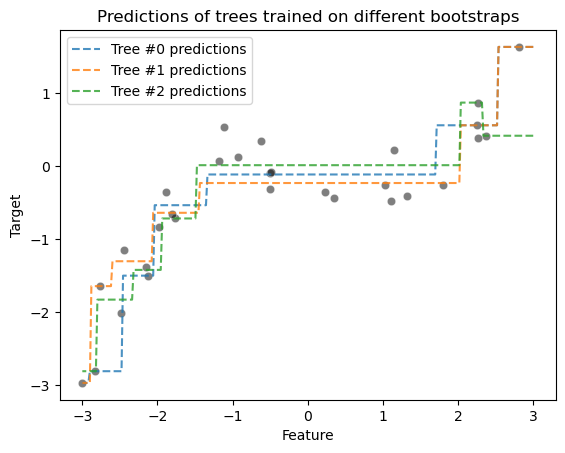

In [11]:
sns.scatterplot(
    x=data_train["Feature"], y=target_train, color="black", alpha=0.5
)
for tree_idx, tree in enumerate(bag_of_trees):
    tree_predictions = tree.predict(data_test)
    plt.plot(
        data_test["Feature"],
        tree_predictions,
        linestyle="--",
        alpha=0.8,
        label=f"Tree #{tree_idx} predictions",
    )

plt.legend()
_ = plt.title("Predictions of trees trained on different bootstraps")

## Aggregating
- Once our trees are fitted, we are able to get predictions for each of them. In
regression, the most straightforward way to combine those predictions is just
to average them: for a given test data point, we feed the input feature values
to each of the `n` trained models in the ensemble and as a result compute `n`
predicted values for the target variable. The final prediction of the ensemble
for the test data point is the average of those `n` values.



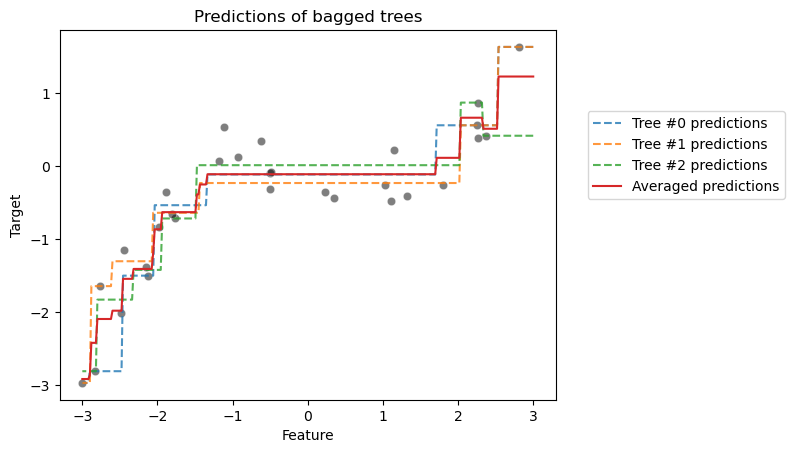

In [12]:
sns.scatterplot(
    x=data_train["Feature"], y=target_train, color="black", alpha=0.5
)

bag_predictions = []
for tree_idx, tree in enumerate(bag_of_trees):
    tree_predictions = tree.predict(data_test)
    plt.plot(
        data_test["Feature"],
        tree_predictions,
        linestyle="--",
        alpha=0.8,
        label=f"Tree #{tree_idx} predictions",
    )
    bag_predictions.append(tree_predictions)

bag_predictions = np.mean(bag_predictions, axis=0)
plt.plot(
    data_test["Feature"],
    bag_predictions,
    label="Averaged predictions",
    linestyle="-",
)
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = plt.title("Predictions of bagged trees")

In [13]:
from sklearn.ensemble import BaggingRegressor

bagged_trees = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=3),
    n_estimators=100,
)
_ = bagged_trees.fit(data_train, target_train)

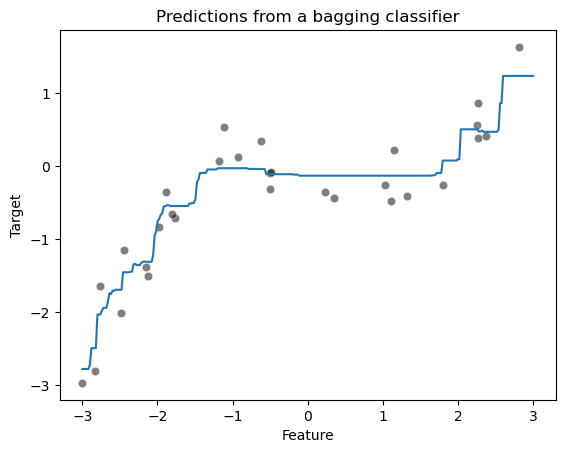

In [14]:
sns.scatterplot(
    x=data_train["Feature"], y=target_train, color="black", alpha=0.5
)

bagged_trees_predictions = bagged_trees.predict(data_test)
plt.plot(data_test["Feature"], bagged_trees_predictions)

_ = plt.title("Predictions from a bagging classifier")

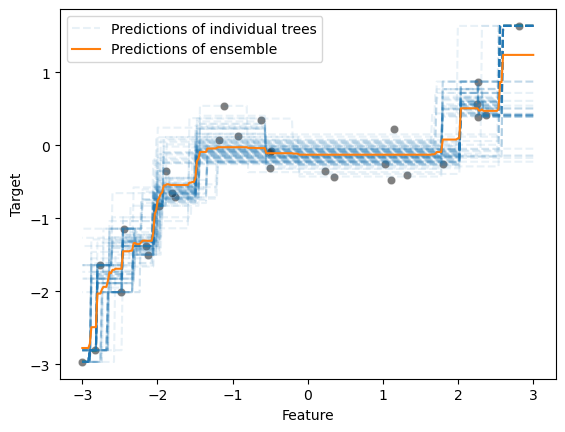

In [15]:
for tree_idx, tree in enumerate(bagged_trees.estimators_):
    label = "Predictions of individual trees" if tree_idx == 0 else None
    # we convert `data_test` into a NumPy array to avoid a warning raised in scikit-learn
    tree_predictions = tree.predict(data_test.to_numpy())
    plt.plot(
        data_test["Feature"],
        tree_predictions,
        linestyle="--",
        alpha=0.1,
        color="tab:blue",
        label=label,
    )

sns.scatterplot(
    x=data_train["Feature"], y=target_train, color="black", alpha=0.5
)

bagged_trees_predictions = bagged_trees.predict(data_test)
plt.plot(
    data_test["Feature"],
    bagged_trees_predictions,
    color="tab:orange",
    label="Predictions of ensemble",
)
_ = plt.legend()

In [16]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline


polynomial_regressor = make_pipeline(
    MinMaxScaler(),
    PolynomialFeatures(degree=4),
    Ridge(alpha=1e-10),
)

- This pipeline first scales the data to the 0-1 range with MinMaxScaler. Then it extracts degree-4 polynomial features. The resulting features will all stay in the 0-1 range by construction: if x lies in the 0-1 range then x ** n also lies in the 0-1 range for any value of n.

- Then the pipeline feeds the resulting non-linear features to a regularized linear regression model for the final prediction of the target variable.

In [17]:
bagging = BaggingRegressor(
    estimator=polynomial_regressor,
    n_estimators=100,
    random_state=0,
)
_ = bagging.fit(data_train, target_train)

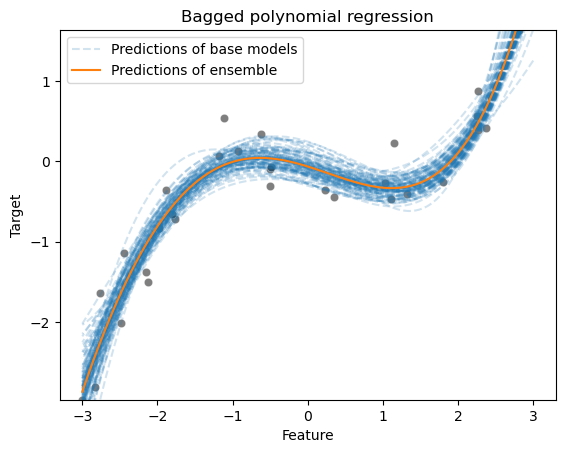

In [18]:
for i, regressor in enumerate(bagging.estimators_):
    # we convert `data_test` into a NumPy array to avoid a warning raised in scikit-learn
    regressor_predictions = regressor.predict(data_test.to_numpy())
    base_model_line = plt.plot(
        data_test["Feature"],
        regressor_predictions,
        linestyle="--",
        alpha=0.2,
        label="Predictions of base models" if i == 0 else None,
        color="tab:blue",
    )

sns.scatterplot(
    x=data_train["Feature"], y=target_train, color="black", alpha=0.5
)
bagging_predictions = bagging.predict(data_test)
plt.plot(
    data_test["Feature"],
    bagging_predictions,
    color="tab:orange",
    label="Predictions of ensemble",
)
plt.ylim(target_train.min(), target_train.max())
plt.legend()
_ = plt.title("Bagged polynomial regression")